In [1]:
# ============================================================
# Tangent Space + LDA
# ============================================================

import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import mne

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace




In [2]:
# =========================
# SETTINGS
# =========================

DATA_DIR = r"E:\Individual and GitHub Projects\Stroke Rehab ( BCI Competition )\stroke-rehab\Data set"  

CH_NAMES = [
    "FC3", "FCz", "FC4",
    "C5", "C3", "C1", "Cz", "C2", "C4", "C6",
    "CP3", "CP1", "CPz", "CP2", "CP4",
    "Pz"
]

EVENT_ID = {
    "left_hand": 1,
    "right_hand": 2
}

SUBJECTS = ["P1", "P2", "P3"]
STAGES = ["pre", "post"]

TMIN = 2.0
TMAX = 8.0
BASELINE = (2.0, 2.5)
L_FREQ = 8.0
H_FREQ = 30.0

N_SPLITS = 5
RANDOM_STATE = 42




In [3]:
# =========================
# PREPROCESSING FUNCTIONS
# =========================

def load_mat_file(filepath, scale_to_volts=True):
    mat = sio.loadmat(filepath)
    fs = int(mat["fs"].squeeze())
    y = mat["y"]
    trig = mat["trig"].squeeze()

    if scale_to_volts:
        y = y * 1e-6

    return y, trig, fs


def extract_events_from_trigger(trig):
    trig = trig.flatten()

    onsets = np.where(np.diff((trig != 0).astype(int)) == 1)[0] + 1
    original_labels = trig[onsets]

    event_codes = np.where(original_labels == 1, 1, 2)

    events = np.column_stack([
        onsets,
        np.zeros(len(onsets), dtype=int),
        event_codes
    ])

    return events, event_codes


def make_raw_from_mat(filepath, l_freq=8.0, h_freq=30.0):
    y, trig, fs = load_mat_file(filepath)

    info = mne.create_info(
        ch_names=CH_NAMES,
        sfreq=fs,
        ch_types=["eeg"] * len(CH_NAMES)
    )

    montage = mne.channels.make_standard_montage("standard_1020")
    info.set_montage(montage, on_missing="ignore")

    raw = mne.io.RawArray(y.T, info, verbose=False)

    raw.set_eeg_reference("average", projection=False, verbose=False)

    raw.filter(
        l_freq=l_freq,
        h_freq=h_freq,
        fir_design="firwin",
        verbose=False
    )

    events, labels = extract_events_from_trigger(trig)

    return raw, events, labels, fs


def make_epochs_from_mat(filepath):
    raw, events, labels, fs = make_raw_from_mat(
        filepath,
        l_freq=L_FREQ,
        h_freq=H_FREQ
    )

    epochs = mne.Epochs(
        raw,
        events,
        event_id=EVENT_ID,
        tmin=TMIN,
        tmax=TMAX,
        baseline=BASELINE,
        preload=True,
        picks="eeg",
        verbose=False
    )

    X = epochs.get_data()
    y = epochs.events[:, 2]

    return epochs, X, y, fs


class ChannelWiseZScore(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.mean_ = X.mean(axis=(0, 2), keepdims=True)
        self.std_ = X.std(axis=(0, 2), keepdims=True)
        self.std_[self.std_ == 0] = 1.0
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_




In [4]:
# =========================
# MODEL
# =========================

def build_tslda_pipeline():
    return Pipeline([
        ("zscore", ChannelWiseZScore()),
        ("cov", Covariances(estimator="lwf")),
        ("ts", TangentSpace(metric="riemann")),
        ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"))
    ])




In [5]:
# =========================
# RUN ONE TRAIN/TEST PAIR
# =========================

def run_one_pair(subject, stage):
    train_file = os.path.join(DATA_DIR, f"{subject}_{stage}_training.mat")
    test_file = os.path.join(DATA_DIR, f"{subject}_{stage}_test.mat")

    print("\n" + "=" * 70)
    print(f"TS-LDA | Subject: {subject} | Stage: {stage.upper()}")
    print("=" * 70)

    train_epochs, X_train, y_train, fs_train = make_epochs_from_mat(train_file)
    test_epochs, X_test, y_test, fs_test = make_epochs_from_mat(test_file)

    print(f"Train file: {train_file}")
    print(f"Test file : {test_file}")
    print(f"Sampling rate: {fs_train} Hz")
    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape : {X_test.shape}")
    print(f"Train labels count: {dict(zip(*np.unique(y_train, return_counts=True)))}")
    print(f"Test labels count : {dict(zip(*np.unique(y_test, return_counts=True)))}")

    model = build_tslda_pipeline()

    cv = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    cv_acc = cv_scores.mean()
    cv_std = cv_scores.std()

    print("\nAccuracies")
    print(f"Training Accuracy : {train_acc * 100:.2f}%")
    print(f"Test Accuracy     : {test_acc * 100:.2f}%")
    print(f"CV Accuracy       : {cv_acc * 100:.2f}% ± {cv_std * 100:.2f}%")

    print("\nClassification Report - TEST")
    print(classification_report(
        y_test,
        y_test_pred,
        target_names=["left_hand", "right_hand"]
    ))

    cm = confusion_matrix(y_test, y_test_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["left_hand", "right_hand"]
    )
    disp.plot(cmap="Blues")
    plt.title(f"TS-LDA Confusion Matrix | {subject} {stage}")
    plt.show()

    return {
        "method": "TS-LDA",
        "subject": subject,
        "stage": stage,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "cv_acc": cv_acc,
        "cv_std": cv_std
    }





TS-LDA | Subject: P1 | Stage: PRE
Train file: E:\Individual and GitHub Projects\Stroke Rehab ( BCI Competition )\stroke-rehab\Data set\P1_pre_training.mat
Test file : E:\Individual and GitHub Projects\Stroke Rehab ( BCI Competition )\stroke-rehab\Data set\P1_pre_test.mat
Sampling rate: 256 Hz
X_train shape: (80, 16, 1537)
X_test shape : (80, 16, 1537)
Train labels count: {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}
Test labels count : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}

Accuracies
Training Accuracy : 100.00%
Test Accuracy     : 90.00%
CV Accuracy       : 96.25% ± 3.06%

Classification Report - TEST
              precision    recall  f1-score   support

   left_hand       0.88      0.93      0.90        40
  right_hand       0.92      0.88      0.90        40

    accuracy                           0.90        80
   macro avg       0.90      0.90      0.90        80
weighted avg       0.90      0.90      0.90        80



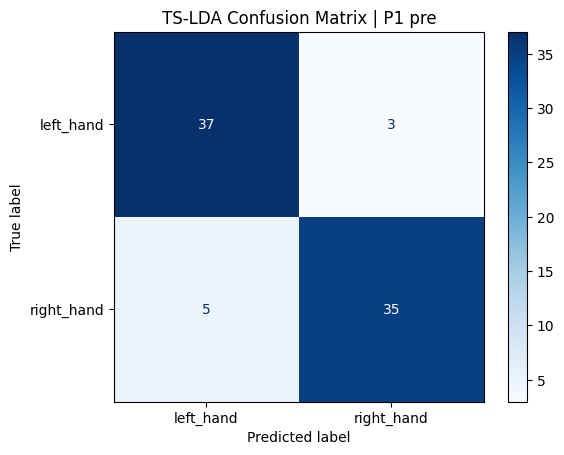


TS-LDA | Subject: P1 | Stage: POST
Train file: E:\Individual and GitHub Projects\Stroke Rehab ( BCI Competition )\stroke-rehab\Data set\P1_post_training.mat
Test file : E:\Individual and GitHub Projects\Stroke Rehab ( BCI Competition )\stroke-rehab\Data set\P1_post_test.mat
Sampling rate: 256 Hz
X_train shape: (79, 16, 1537)
X_test shape : (80, 16, 1537)
Train labels count: {np.int64(1): np.int64(39), np.int64(2): np.int64(40)}
Test labels count : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}

Accuracies
Training Accuracy : 100.00%
Test Accuracy     : 91.25%
CV Accuracy       : 96.25% ± 5.00%

Classification Report - TEST
              precision    recall  f1-score   support

   left_hand       0.88      0.95      0.92        40
  right_hand       0.95      0.88      0.91        40

    accuracy                           0.91        80
   macro avg       0.91      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80



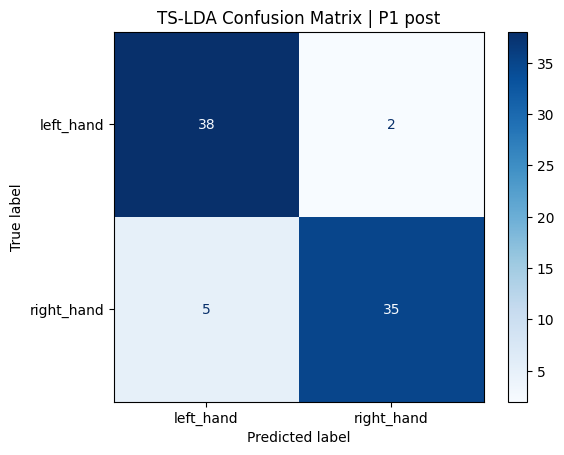


TS-LDA | Subject: P2 | Stage: PRE
Train file: E:\Individual and GitHub Projects\Stroke Rehab ( BCI Competition )\stroke-rehab\Data set\P2_pre_training.mat
Test file : E:\Individual and GitHub Projects\Stroke Rehab ( BCI Competition )\stroke-rehab\Data set\P2_pre_test.mat
Sampling rate: 256 Hz
X_train shape: (80, 16, 1537)
X_test shape : (80, 16, 1537)
Train labels count: {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}
Test labels count : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}

Accuracies
Training Accuracy : 100.00%
Test Accuracy     : 73.75%
CV Accuracy       : 86.25% ± 7.29%

Classification Report - TEST
              precision    recall  f1-score   support

   left_hand       0.79      0.65      0.71        40
  right_hand       0.70      0.82      0.76        40

    accuracy                           0.74        80
   macro avg       0.75      0.74      0.74        80
weighted avg       0.75      0.74      0.74        80



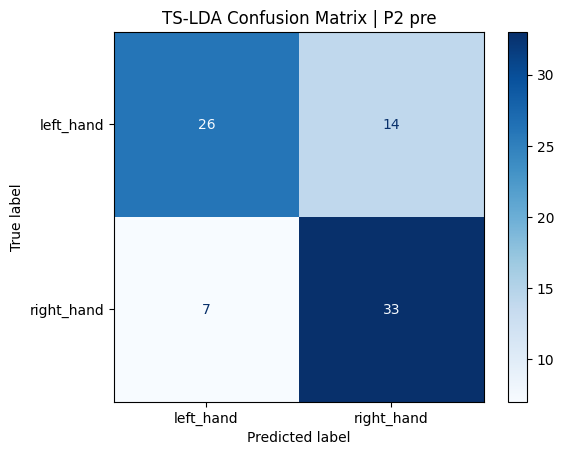


TS-LDA | Subject: P2 | Stage: POST
Train file: E:\Individual and GitHub Projects\Stroke Rehab ( BCI Competition )\stroke-rehab\Data set\P2_post_training.mat
Test file : E:\Individual and GitHub Projects\Stroke Rehab ( BCI Competition )\stroke-rehab\Data set\P2_post_test.mat
Sampling rate: 256 Hz
X_train shape: (80, 16, 1537)
X_test shape : (80, 16, 1537)
Train labels count: {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}
Test labels count : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}

Accuracies
Training Accuracy : 100.00%
Test Accuracy     : 91.25%
CV Accuracy       : 91.25% ± 6.37%

Classification Report - TEST
              precision    recall  f1-score   support

   left_hand       0.90      0.93      0.91        40
  right_hand       0.92      0.90      0.91        40

    accuracy                           0.91        80
   macro avg       0.91      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80



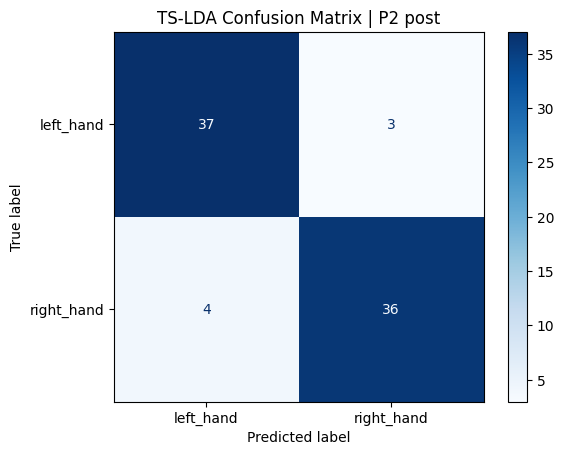


TS-LDA | Subject: P3 | Stage: PRE
Train file: E:\Individual and GitHub Projects\Stroke Rehab ( BCI Competition )\stroke-rehab\Data set\P3_pre_training.mat
Test file : E:\Individual and GitHub Projects\Stroke Rehab ( BCI Competition )\stroke-rehab\Data set\P3_pre_test.mat
Sampling rate: 256 Hz
X_train shape: (79, 16, 1537)
X_test shape : (79, 16, 1537)
Train labels count: {np.int64(1): np.int64(40), np.int64(2): np.int64(39)}
Test labels count : {np.int64(1): np.int64(40), np.int64(2): np.int64(39)}

Accuracies
Training Accuracy : 100.00%
Test Accuracy     : 93.67%
CV Accuracy       : 97.42% ± 3.17%

Classification Report - TEST
              precision    recall  f1-score   support

   left_hand       0.89      1.00      0.94        40
  right_hand       1.00      0.87      0.93        39

    accuracy                           0.94        79
   macro avg       0.94      0.94      0.94        79
weighted avg       0.94      0.94      0.94        79



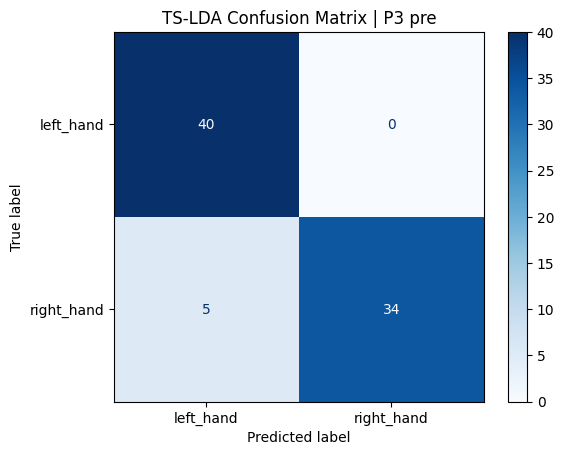


TS-LDA | Subject: P3 | Stage: POST
Train file: E:\Individual and GitHub Projects\Stroke Rehab ( BCI Competition )\stroke-rehab\Data set\P3_post_training.mat
Test file : E:\Individual and GitHub Projects\Stroke Rehab ( BCI Competition )\stroke-rehab\Data set\P3_post_test.mat
Sampling rate: 256 Hz
X_train shape: (80, 16, 1537)
X_test shape : (80, 16, 1537)
Train labels count: {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}
Test labels count : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}

Accuracies
Training Accuracy : 100.00%
Test Accuracy     : 95.00%
CV Accuracy       : 86.25% ± 7.29%

Classification Report - TEST
              precision    recall  f1-score   support

   left_hand       0.93      0.97      0.95        40
  right_hand       0.97      0.93      0.95        40

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80



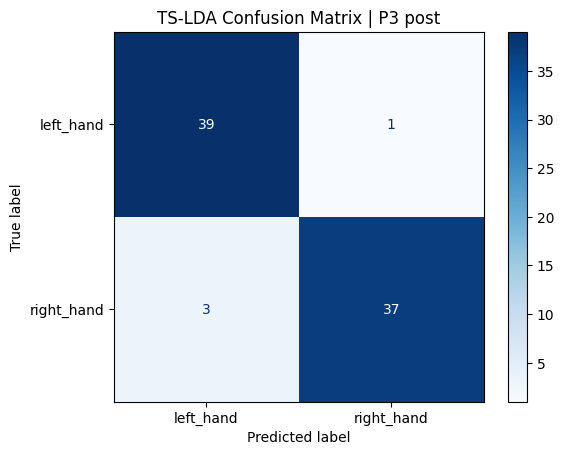

In [6]:
# =========================
# RUN ALL
# =========================

tslda_results = []

for subject in SUBJECTS:
    for stage in STAGES:
        result = run_one_pair(subject, stage)
        tslda_results.append(result)






TS-LDA SUMMARY
P1  pre | Train: 100.00% | Test:  90.00% | CV:  96.25% ± 3.06%
P1 post | Train: 100.00% | Test:  91.25% | CV:  96.25% ± 5.00%
P2  pre | Train: 100.00% | Test:  73.75% | CV:  86.25% ± 7.29%
P2 post | Train: 100.00% | Test:  91.25% | CV:  91.25% ± 6.37%
P3  pre | Train: 100.00% | Test:  93.67% | CV:  97.42% ± 3.17%
P3 post | Train: 100.00% | Test:  95.00% | CV:  86.25% ± 7.29%


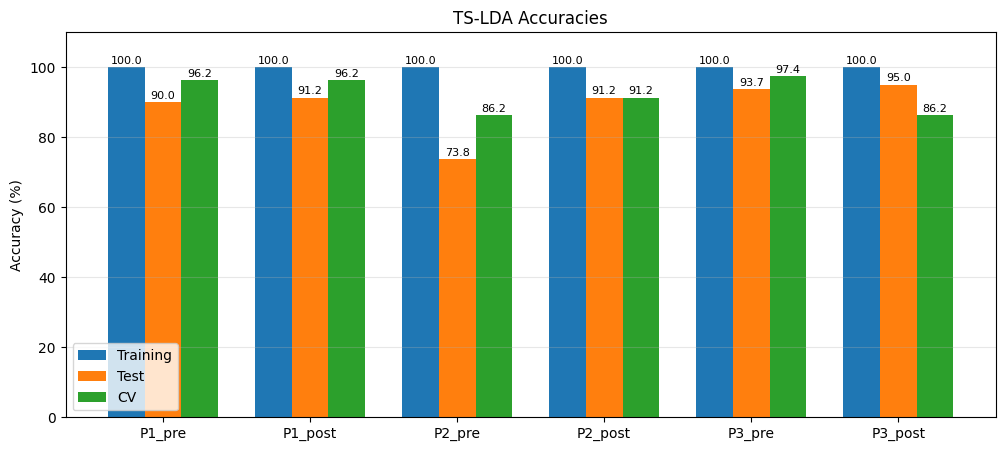

In [7]:
# =========================
# SUMMARY TABLE + BAR PLOT
# =========================

print("\n\nTS-LDA SUMMARY")
print("=" * 70)

for r in tslda_results:
    print(
        f"{r['subject']} {r['stage']:>4} | "
        f"Train: {r['train_acc']*100:6.2f}% | "
        f"Test: {r['test_acc']*100:6.2f}% | "
        f"CV: {r['cv_acc']*100:6.2f}% ± {r['cv_std']*100:.2f}%"
    )

labels = [f"{r['subject']}_{r['stage']}" for r in tslda_results]
train_accs = [r["train_acc"] * 100 for r in tslda_results]
test_accs = [r["test_acc"] * 100 for r in tslda_results]
cv_accs = [r["cv_acc"] * 100 for r in tslda_results]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(12, 5))
plt.bar(x - width, train_accs, width, label="Training")
plt.bar(x, test_accs, width, label="Test")
plt.bar(x + width, cv_accs, width, label="CV")

plt.xticks(x, labels)
plt.ylabel("Accuracy (%)")
plt.title("TS-LDA Accuracies")
plt.ylim(0, 110)
plt.legend()
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(train_accs):
    plt.text(i - width, v + 1, f"{v:.1f}", ha="center", fontsize=8)
for i, v in enumerate(test_accs):
    plt.text(i, v + 1, f"{v:.1f}", ha="center", fontsize=8)
for i, v in enumerate(cv_accs):
    plt.text(i + width, v + 1, f"{v:.1f}", ha="center", fontsize=8)

plt.show()